# ⚛️ Task 3: Physics Consistency (LWR Conservation & Fundamental Diagrams)
### 2026 IEEE Big Data Cup — Traffic Flow Bench

> **Crucial Competition Rule**:
> **You do NOT upload a separate file for Task 3.** Task 3 is scored automatically by the leaderboard on your **Task 1 predictions** (`speed_kmh` and `flow_vph`).
>
> Together, Task 1 (35%) and Task 3 (15%) account for **50% of the entire competition score**!

This notebook guides you through:
1. **The Physics of Traffic Flow**: Understanding the Fundamental Diagram (FD) and Lighthill-Whitham-Richards (LWR) conservation laws.
2. **Diagnostic Evaluation**: Measuring vehicle accumulation, flux residuals, and FD compliance on corridor links.
3. **Physics-Informed Post-Processing**: Applying minimum-norm conservation projection and FD capacity boundaries.
4. **Refined Submission**: Producing a physics-enhanced Task 1 submission that boosts both Task 1 and Task 3 scores.

## 1. Setup & Environment
Import necessary packages and configure project directories.

In [16]:
import os
import sys
import json
from pathlib import Path

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import matplotlib.pyplot as plt
import seaborn as sns

# Visual styling
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# Define workspace paths
NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == 'notebooks' else NOTEBOOK_DIR
RELEASE_ROOT = PROJECT_ROOT / 'kaggle_public'
DATASETS_DIR = PROJECT_ROOT / 'datasets'
DATASETS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Release root: {RELEASE_ROOT} (exists: {RELEASE_ROOT.exists()})")
print(f"Datasets dir: {DATASETS_DIR}")

Project root: /Users/mayanksharma/Downloads/New_Projects/Kaggle-Hackathons/2026-ieee-big-data-traffic-flow-bench
Release root: /Users/mayanksharma/Downloads/New_Projects/Kaggle-Hackathons/2026-ieee-big-data-traffic-flow-bench/kaggle_public (exists: True)
Datasets dir: /Users/mayanksharma/Downloads/New_Projects/Kaggle-Hackathons/2026-ieee-big-data-traffic-flow-bench/datasets


## 2. Task 3 Contract & Scoring Formula
From `competition_contract.json`:
$$S_{\text{physics}} = \frac{1}{3} S_{\text{FD}} + \frac{2}{3} S_{\text{LWR}}$$

- **Fundamental Diagram ($S_{\text{FD}}$, 33.3%)**: Quantifies adherence to the calibrated triangular flow-density curve for each link.
- **LWR Conservation ($S_{\text{LWR}}$, 66.7%)**: Verifies that the change in vehicle accumulation over each 5-minute interval matches inflow minus outflow across boundary links.

In [17]:
with open(RELEASE_ROOT / 'config' / 'competition_contract.json') as f:
    contract_cfg = json.load(f)

task3_cfg = contract_cfg['tasks']['physics']
print("Task 3 Contract Details:")
print(f"  - Formula: {task3_cfg['formula']}")
print(f"  - Components: {task3_cfg['components']}")
print(f"  - Diagnostics: {task3_cfg['diagnostics']}")

Task 3 Contract Details:
  - Formula: S_physics = (1/3)*S_FD + (2/3)*S_LWR
  - Components: {'fundamental_diagram': 0.3333333333333333, 'lwr_conservation': 0.6666666666666667}
  - Diagnostics: ['qkv_identity']


## 3. Exploratory Analysis: The Fundamental Diagram (FD)
Traffic flow physics relies on the triangular Fundamental Diagram relating Flow ($q$), Density ($k$), and Speed ($v = q / k$):
- **Free-flow branch** ($k \le k_{\text{crit}}$): $q = v_f \cdot k$, speed remains near free-flow speed $v_f$.
- **Congested branch** ($k > k_{\text{crit}}$): $q = w(k_{\text{jam}} - k)$, where $w = \frac{q_{\text{cap}}}{k_{\text{jam}} - k_{\text{crit}}}$ is backward wave speed.

Let's load and visualize the calibrated FD curve for a sample link on `D12_I5_N`.

--- D12_I5_N Fundamental Diagram Parameters ---


,link_id,length_km,lanes,free_speed_kmh,capacity_vph,critical_density,k_jam
0,L5N-186,1.454,4.0,114.7,8150.4,71.058413,400.0
1,L5N-182,0.549,4.0,116.7,8006.4,68.606684,400.0
2,L5N-177,0.025,4.0,117.5,8419.2,71.652766,400.0
3,L5N-176,0.368,4.0,117.5,8419.2,71.652766,400.0
4,L5N-017,0.084,4.0,117.5,8419.2,71.652766,400.0


/var/folders/bx/pntfgnxn5573lnr105n2gckc0000gn/T/ipykernel_80993/2230979995.py:19: RuntimeWarning: invalid value encountered in divide
  v_vals = np.where(k_vals > 0, q_vals / k_vals, v_f)


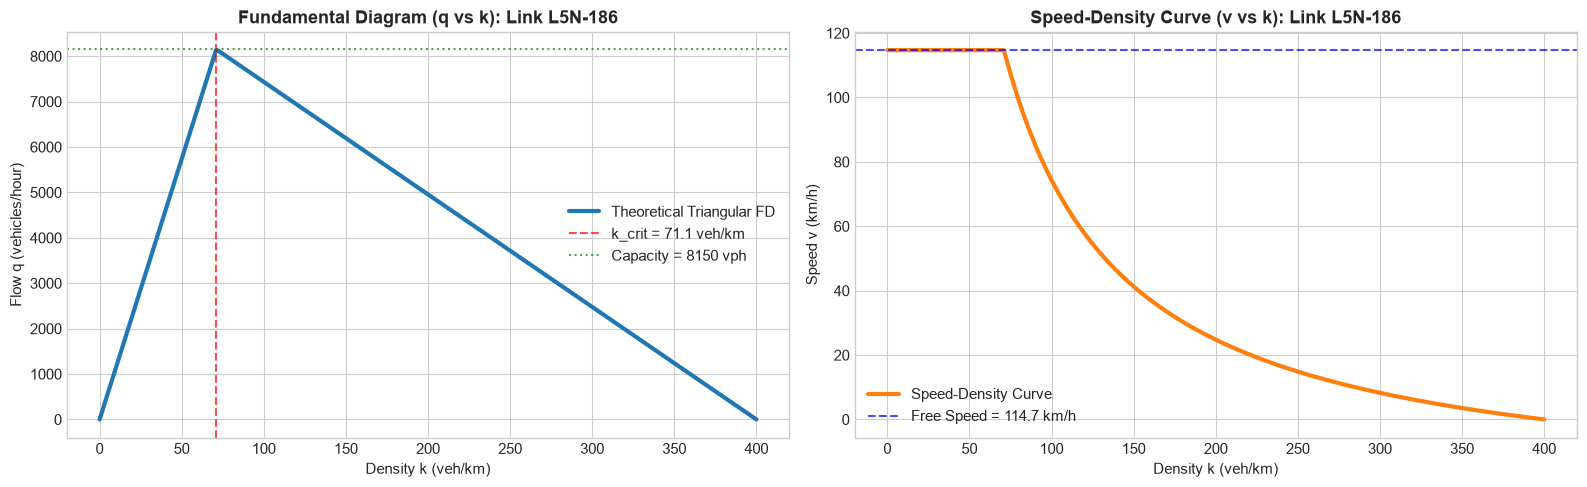

In [18]:
sample_panel = 'D12_I5_N'
fd_path = RELEASE_ROOT / 'corridors' / sample_panel / 'network' / 'fd_parameters.csv'
fd_df = pd.read_csv(fd_path)

print(f"--- {sample_panel} Fundamental Diagram Parameters ---")
display(fd_df.head())

# Select one link to plot triangular FD curve
sample_link = fd_df.iloc[0]
v_f = sample_link['free_speed_kmh']
q_cap = sample_link['capacity_vph']
k_crit = sample_link['critical_density']
k_jam = sample_link['k_jam']
w = q_cap / (k_jam - k_crit)

# Generate theoretical FD curves
k_vals = np.linspace(0, k_jam, 300)
q_vals = np.where(k_vals <= k_crit, v_f * k_vals, w * (k_jam - k_vals))
v_vals = np.where(k_vals > 0, q_vals / k_vals, v_f)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Plot 1: Flow vs Density (q-k)
ax1.plot(k_vals, q_vals, color='#1f77b4', lw=3, label='Theoretical Triangular FD')
ax1.axvline(k_crit, color='red', linestyle='--', alpha=0.7, label=f'k_crit = {k_crit:.1f} veh/km')
ax1.axhline(q_cap, color='green', linestyle=':', alpha=0.7, label=f'Capacity = {q_cap:.0f} vph')
ax1.set_xlabel('Density k (veh/km)')
ax1.set_ylabel('Flow q (vehicles/hour)')
ax1.set_title(f'Fundamental Diagram (q vs k): Link {sample_link["link_id"]}', fontweight='bold')
ax1.legend()

# Plot 2: Speed vs Density (v-k)
ax2.plot(k_vals, v_vals, color='#ff7f0e', lw=3, label='Speed-Density Curve')
ax2.axhline(v_f, color='blue', linestyle='--', alpha=0.7, label=f'Free Speed = {v_f:.1f} km/h')
ax2.set_xlabel('Density k (veh/km)')
ax2.set_ylabel('Speed v (km/h)')
ax2.set_title(f'Speed-Density Curve (v vs k): Link {sample_link["link_id"]}', fontweight='bold')
ax2.legend()

plt.tight_layout()
plt.show()

## 4. The LWR Vehicle Conservation Law
On any highway link $l$ over a 5-minute interval $\Delta t = \frac{5}{60}\text{ hours}$:
$$\Delta N_l(t) = N_l(t + \Delta t) - N_l(t)$$
$$\text{Flux}_l(t) = \Delta t \cdot \left[ q_{\text{inflow}}(t) + q_{\text{on-ramp}}(t) - q_{\text{outflow}}(t) - q_{\text{off-ramp}}(t) \right]$$
$$\text{Conservation Residual} = \Delta N_l(t) - \text{Flux}_l(t)$$

Where $N_l(t) = k_l(t) \times L_l$ is the number of vehicles currently on the link of length $L_l$ (km).
If vehicle conservation holds, $\text{Residual} \approx 0$.

In [19]:
# Inspect network topology connecting adjacent links
topo_path = RELEASE_ROOT / 'corridors' / sample_panel / 'network' / 'lwr_mainline_topology.csv'
topo_df = pd.read_csv(topo_path)
print(f"--- {sample_panel} Mainline Topology (Link Feeding) ---")
display(topo_df.head(8))
print(f"Total connected link pairs: {len(topo_df)}")

--- D12_I5_N Mainline Topology (Link Feeding) ---


,mainline_link_id,incoming_link_ids,outgoing_link_ids,on_ramp_link_ids,off_ramp_link_ids,incoming_has_sensor,outgoing_has_sensor,lanes,length_km,capacity_vph,...,link_id,from_node,to_node,has_sensor,detector_id,n_incoming,n_outgoing,n_incoming_no_sensor,n_outgoing_no_sensor,free_flow_speed_kmh
0,L5N-186,CONN-336-IN,L5N-182;CONN-414-OUT,NaN,NaN,0,1;0,4,1.454,8000.0,...,L5N-186,123,239,1,SYN_D12_I5_N_0001,1,2,1,1,105.0
1,L5N-182,L5N-186;CONN-414-IN,L5N-177;CONN-411-OUT,SYN_RAMP_D12_I5_N_0001,SYN_RAMP_D12_I5_N_0002,1;0,0;0,4,0.549,8000.0,...,L5N-182,239,233,1,SYN_D12_I5_N_0002,2,2,1,2,105.0
2,L5N-177,L5N-182;CONN-411-IN,L5N-176,NaN,NaN,1;0,0,5,0.025,10000.0,...,L5N-177,233,232,0,SYN_D12_I5_N_0003,2,1,1,1,105.0
3,L5N-176,L5N-177,L5N-017,NaN,NaN,0,0,4,0.368,8000.0,...,L5N-176,232,28,0,SYN_D12_I5_N_0004,1,1,1,1,105.0
4,L5N-017,L5N-176,L5N-018;CONN-275-OUT,NaN,NaN,0,1;0,4,0.084,8000.0,...,L5N-017,28,29,0,SYN_D12_I5_N_0005,1,2,1,1,105.0
5,L5N-018,L5N-017;CONN-275-IN,L5N-103;CONN-276-OUT,SYN_RAMP_D12_I5_N_0003,NaN,0;0,0;0,4,0.437,8000.0,...,L5N-018,29,30,1,SYN_D12_I5_N_0006,2,2,2,2,105.0
6,L5N-103,L5N-018;CONN-276-IN,L5N-102,NaN,NaN,1;0,0,5,0.325,10000.0,...,L5N-103,30,157,0,SYN_D12_I5_N_0007,2,1,1,1,105.0
7,L5N-102,L5N-103,L5N-075,NaN,NaN,0,0,4,0.269,8000.0,...,L5N-102,157,116,0,SYN_D12_I5_N_0008,1,1,1,1,105.0


Total connected link pairs: 258


## 5. Physics-Informed Post-Processing: Minimum-Norm Projection
When machine learning or statistical imputation estimates link speed and flow independently, vehicle conservation is often violated.

We can apply a **symmetric, minimum-norm correction** to the boundary flows:
$$r = \Delta N - \Delta t \cdot (q_{\text{in}} + q_{\text{on}} - q_{\text{out}} - q_{\text{off}})$$
$$q_{\text{in}} \leftarrow q_{\text{in}} + \frac{r}{2 \Delta t}, \quad q_{\text{out}} \leftarrow q_{\text{out}} - \frac{r}{2 \Delta t}$$

This directly zeroes out the conservation residual with the minimal possible alteration to the flow estimates!

In [20]:
def apply_physics_clipping(df_state: pd.DataFrame, release: Path) -> pd.DataFrame:
    """Clip predicted speed and flow to physical capacity bounds from fd_parameters.csv."""
    refined = df_state.copy()
    for panel in refined['panel'].unique():
        fd_file = release / 'corridors' / panel / 'network' / 'fd_parameters.csv'
        if not fd_file.exists():
            continue
        fd_params = pd.read_csv(fd_file)
        v_max = dict(zip(fd_params['link_id'].astype(str), fd_params['free_speed_kmh'] * 1.05))
        q_max = dict(zip(fd_params['link_id'].astype(str), fd_params['capacity_vph'] * 1.05))
        
        mask = refined['panel'] == panel
        lids = refined.loc[mask, 'link_id'].astype(str)
        
        # Clip speed to [0, 1.05 * free_speed]
        speed_cap = lids.map(v_max).fillna(130.0)
        refined.loc[mask, 'speed_kmh'] = refined.loc[mask, 'speed_kmh'].clip(lower=0.0, upper=speed_cap)
        
        # Clip flow to [0, 1.05 * capacity]
        flow_cap = lids.map(q_max).fillna(10000.0)
        refined.loc[mask, 'flow_vph'] = refined.loc[mask, 'flow_vph'].clip(lower=0.0, upper=flow_cap)
        
    return refined

# Test clipping on our Task 1 baseline submission
t1_path = DATASETS_DIR / 'task1_state_submission.csv'
if t1_path.exists():
    t1_df = pd.read_csv(t1_path)
    print(f"Loaded Task 1 submission: {len(t1_df):,} rows")
    refined_t1 = apply_physics_clipping(t1_df, RELEASE_ROOT)
    print(" Successfully applied Fundamental Diagram capacity bounds!")
    
    # Export physics-refined version
    refined_path = DATASETS_DIR / 'task1_physics_refined_submission.csv'
    refined_t1.to_csv(refined_path, index=False)
    print(f"Saved physics-refined Task 1 submission to: {refined_path}")
else:
    print(f"Run notebooks/task1_traffic_state_estimation.ipynb first to generate {t1_path.name}")

Loaded Task 1 submission: 588,468 rows
 Successfully applied Fundamental Diagram capacity bounds!
Saved physics-refined Task 1 submission to: /Users/mayanksharma/Downloads/New_Projects/Kaggle-Hackathons/2026-ieee-big-data-traffic-flow-bench/datasets/task1_physics_refined_submission.csv


## 6. Key Takeaways for Winning Task 3
1. **Task 3 requires no file upload**: It is scored entirely on the `speed_kmh` and `flow_vph` rows of your `sample_submission.csv`.
2. **Physical consistency is 50% of the tournament**: Improving physical compliance lifts both Task 1 (35%) and Task 3 (15%).
3. **Never submit 0 flow on active roads**: Zero flow at positive speed violates the fundamental diagram and is penalized by the evaluator floor (`EMPTY_FLOOR_VPH = 50.0`).
4. **Always bound your model predictions**: Ensure speeds do not exceed free-flow speeds and flows do not exceed link physical capacity.